# Beginner AI/ML in Water Resources  
## Groundwater prediction example for coastal Miami (Biscayne aquifer)

This notebook recreates the **same multi-method teaching example** as the earlier streamflow notebook, but now for **groundwater levels** in the **Miami coastal area**.

### What this notebook predicts
1. **Regression task:** predict **tomorrow's groundwater level**
2. **Classification task:** predict whether **tomorrow will be a high-groundwater day**

### Methods compared
- **Linear Regression**
- **Logistic Regression**
- **Random Forest**
- **XGBoost**
- **LSTM**

### Study location
We use **USGS well G-580A (site 254000080181002)** in the **Biscayne aquifer** near coastal Miami.  
The weather inputs are taken for the same area using a gridded weather API.

### Predictors
- recent **groundwater level**
- recent **rainfall**
- recent **reference evapotranspiration (ET₀)**

### Why this is a good beginner example
In coastal south Florida, groundwater is shallow and strongly influenced by:
- rainfall recharge
- evapotranspiration losses
- persistence from previous groundwater conditions

That makes it a nice example for showing the difference between:
- simple linear models
- tree-based ML models
- sequence models such as LSTM

## Hydrologic note

For this site, the downloaded USGS daily groundwater series is served as a **daily groundwater elevation time series**  
(parameter **62610**, groundwater level above **NGVD 1929**, in feet).  
In this notebook we use that daily groundwater-level series directly as the prediction target.

Because groundwater usually changes **more slowly** than streamflow, we use:
- a slightly richer set of lagged features, and
- a **14-day sequence window** for the LSTM

## Modeling plan
1. Load groundwater data for the Miami-area well
2. Load daily weather data for the same location:  
   - rainfall  
   - reference evapotranspiration (ET₀)
3. Build lagged features and short input sequences
4. Train several beginner-friendly AI/ML models for **next-day groundwater prediction**
5. Compare the models with regression and classification metrics
6. Use the trained regression models in **recursive mode** to forecast groundwater level for the **next 7 days**

This keeps the notebook easy to teach: first show one-day-ahead learning, then show how that same model can be rolled forward into a short operational forecast.

# Disclaimer: 
Portions of this code were developed with assistance from ChatGPT and were subsequently reviewed, edited, 
and organized for instructional use. The code is provided as a teaching example only and has not been fully
validated for professional engineering, regulatory, design, or safety-critical applications. Users are responsible 
for independently checking assumptions, data quality, parameter choices, numerical results, and suitability 
for any specific water resources application.

In [4]:
# ============================================================
# 1. Imports, configuration, and setup
# ============================================================
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "This notebook requires shap for model interpretation. Install it with: pip install shap"
    ) from exc

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.impute import SimpleImputer

try:
    from xgboost import XGBRegressor, XGBClassifier
except ImportError as exc:
    raise ImportError(
        "This notebook requires xgboost. Install it with: pip install xgboost"
    ) from exc

try:
    import torch
    from torch import nn
    from torch.utils.data import TensorDataset, DataLoader
except ImportError as exc:
    raise ImportError(
        "This notebook requires PyTorch. Install it with: pip install torch"
    ) from exc

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.set_num_threads(1)

# Site and forecast configuration
GW_SITE_NO = "254000080181002"   # USGS G-580A
SITE_LAT = 25.667094
SITE_LON = -80.302564
TIMEZONE = "America/New_York"
HISTORY_START_DATE = "2008-01-01"
HISTORY_END_DATE = (pd.Timestamp.today().normalize() - pd.Timedelta(days=1)).strftime("%Y-%m-%d")
FORECAST_HORIZON_DAYS = 7

print("PyTorch version:", torch.__version__)
print("Random state:", RANDOM_STATE)
print("SHAP version:", shap.__version__)
print("Historical data window:", HISTORY_START_DATE, "to", HISTORY_END_DATE)
print("Forecast horizon (days):", FORECAST_HORIZON_DAYS)

PyTorch version: 2.9.0+cpu
Random state: 42
SHAP version: 0.50.0
Historical data window: 2008-01-01 to 2026-04-11
Forecast horizon (days): 7


In [6]:
# ============================================================
# 2. Load local groundwater CSV or download it from USGS
# ============================================================
gw_candidate_paths = [
    Path("usgs_g580a_daily_groundwater_2008_2026.csv"),
    Path("./usgs_g580a_daily_groundwater_2008_2026.csv"),
    Path("/mnt/data/usgs_g580a_daily_groundwater_2008_2026.csv"),
]

gw_path = None
for p in gw_candidate_paths:
    if p.exists() and p.stat().st_size > 100:
        gw_path = p
        break

if gw_path is not None:
    print("Using local groundwater CSV:", gw_path)
    df_gw = pd.read_csv(gw_path)
else:
    gw_url = (
        "https://waterservices.usgs.gov/nwis/dv/"
        "?format=rdb"
        f"&sites={GW_SITE_NO}"
        "&parameterCd=62610"
        "&siteStatus=all"
        f"&startDT={HISTORY_START_DATE}"
        f"&endDT={HISTORY_END_DATE}"
    )
    print("No local groundwater CSV found. Attempting USGS download...")
    print(gw_url)

    try:
        raw = pd.read_csv(gw_url, sep="	", comment="#")
        raw = raw[raw["agency_cd"] != "5s"].copy()

        value_col = [c for c in raw.columns if c.endswith("_62610_00001")]
        qual_col = [c for c in raw.columns if c.endswith("_62610_00001_cd")]

        if len(value_col) != 1 or len(qual_col) != 1:
            raise ValueError("Could not identify groundwater value columns in the USGS file.")

        df_gw = pd.DataFrame({
            "date": pd.to_datetime(raw["datetime"]),
            "groundwater_level_ft_ngvd29": pd.to_numeric(raw[value_col[0]], errors="coerce"),
            "qualifier": raw[qual_col[0]].astype(str),
        })
        df_gw.to_csv("usgs_g580a_daily_groundwater_2008_2026.csv", index=False)
        print("Saved groundwater CSV locally.")
    except Exception as exc:
        raise RuntimeError(
            "Groundwater data could not be downloaded in this environment. "
            "Please rerun with internet access, or place usgs_g580a_daily_groundwater_2008_2026.csv "
            "in the notebook folder."
        ) from exc

df_gw["date"] = pd.to_datetime(df_gw["date"])
df_gw = df_gw.sort_values("date").reset_index(drop=True)

display(df_gw.head())
print(df_gw.info())
print("Date range:", df_gw["date"].min().date(), "to", df_gw["date"].max().date())

No local groundwater CSV found. Attempting USGS download...
https://waterservices.usgs.gov/nwis/dv/?format=rdb&sites=254000080181002&parameterCd=62610&siteStatus=all&startDT=2008-01-01&endDT=2026-04-11
Saved groundwater CSV locally.


,date,groundwater_level_ft_ngvd29,qualifier
0,2008-01-01,2.40,A
1,2008-01-02,2.39,A
2,2008-01-03,2.34,A
3,2008-01-04,2.32,A
4,2008-01-05,2.34,A


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6451 entries, 0 to 6450
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         6451 non-null   datetime64[ns]
 1   groundwater_level_ft_ngvd29  6451 non-null   float64       
 2   qualifier                    6451 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 151.3+ KB
None
Date range: 2008-01-01 to 2026-04-11


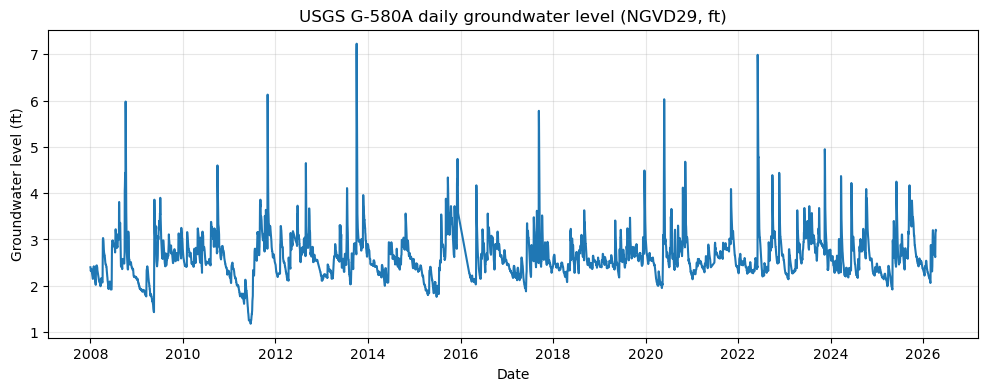

In [8]:
# Quick look at the groundwater time series
plt.figure(figsize=(12, 4))
plt.plot(df_gw["date"], df_gw["groundwater_level_ft_ngvd29"])
plt.title("USGS G-580A daily groundwater level (NGVD29, ft)")
plt.xlabel("Date")
plt.ylabel("Groundwater level (ft)")
plt.grid(True, alpha=0.3)
plt.show()

## Load rainfall and ET₀ data

To keep the notebook easy to run, the weather data are pulled from **Open-Meteo Historical Weather API**  
for the groundwater-well area using the well coordinates:

- latitude = **25.667094**
- longitude = **-80.302564**

Requested daily weather variables:
- `precipitation_sum`
- `et0_fao_evapotranspiration`

If you already have a local weather CSV, the notebook will use that instead.

In [11]:
# ============================================================
# 3. Load local weather CSV or download from Open-Meteo archive
# ============================================================
weather_candidate_paths = [
    Path("g580a_openmeteo_daily_weather_2008_2026.csv"),
    Path("./g580a_openmeteo_daily_weather_2008_2026.csv"),
    Path("/mnt/data/g580a_openmeteo_daily_weather_2008_2026.csv"),
]

weather_path = None
for p in weather_candidate_paths:
    if p.exists() and p.stat().st_size > 100:
        weather_path = p
        break

if weather_path is not None:
    print("Using local weather CSV:", weather_path)
    df_weather = pd.read_csv(weather_path)
else:
    weather_url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={SITE_LAT}"
        f"&longitude={SITE_LON}"
        f"&start_date={HISTORY_START_DATE}"
        f"&end_date={HISTORY_END_DATE}"
        "&daily=precipitation_sum,et0_fao_evapotranspiration"
        f"&timezone={TIMEZONE.replace('/', '%2F')}"
    )
    print("No local weather CSV found. Attempting Open-Meteo download...")
    print(weather_url)

    try:
        with urllib.request.urlopen(weather_url) as response:
            payload = json.loads(response.read().decode("utf-8"))

        daily = payload.get("daily", None)
        if daily is None:
            raise ValueError("Open-Meteo response did not contain a 'daily' block.")

        df_weather = pd.DataFrame({
            "date": pd.to_datetime(daily["time"]),
            "rain_mm": pd.to_numeric(daily["precipitation_sum"], errors="coerce"),
            "et0_mm": pd.to_numeric(daily["et0_fao_evapotranspiration"], errors="coerce"),
        })
        df_weather.to_csv("g580a_openmeteo_daily_weather_2008_2026.csv", index=False)
        print("Saved weather CSV locally.")
    except Exception as exc:
        raise RuntimeError(
            "Weather data could not be downloaded in this environment. "
            "Please rerun with internet access, or place g580a_openmeteo_daily_weather_2008_2026.csv "
            "in the notebook folder."
        ) from exc

df_weather["date"] = pd.to_datetime(df_weather["date"])
df_weather = df_weather.sort_values("date").reset_index(drop=True)

display(df_weather.head())
print(df_weather.info())

No local weather CSV found. Attempting Open-Meteo download...
https://archive-api.open-meteo.com/v1/archive?latitude=25.667094&longitude=-80.302564&start_date=2008-01-01&end_date=2026-04-11&daily=precipitation_sum,et0_fao_evapotranspiration&timezone=America%2FNew_York
Saved weather CSV locally.


,date,rain_mm,et0_mm
0,2008-01-01,12.0,2.46
1,2008-01-02,0.2,4.82
2,2008-01-03,0.0,3.31
3,2008-01-04,1.0,3.35
4,2008-01-05,0.8,2.68


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6676 entries, 0 to 6675
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     6676 non-null   datetime64[ns]
 1   rain_mm  6676 non-null   float64       
 2   et0_mm   6676 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 156.6 KB
None


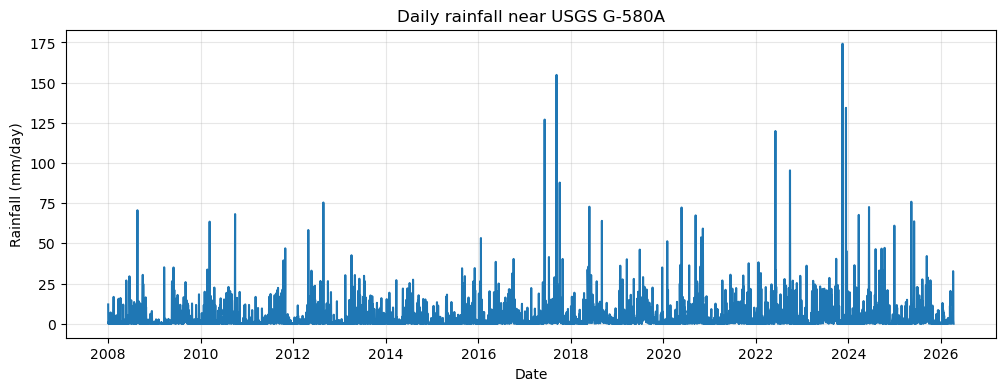

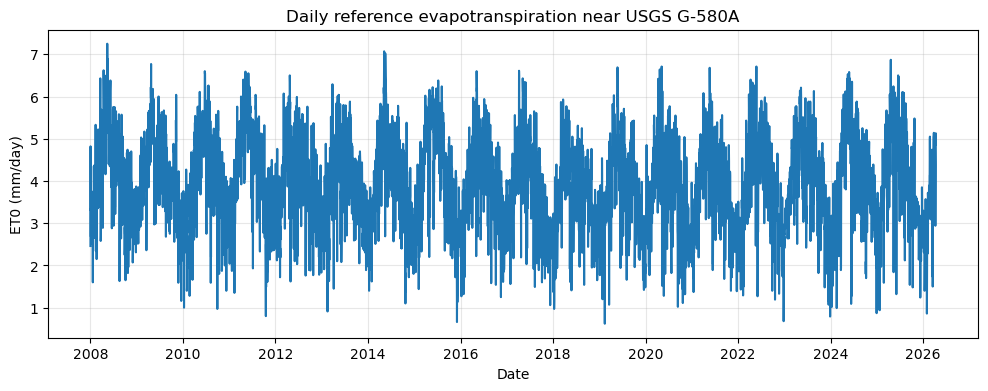

In [13]:
# Quick look at rainfall and ET0
plt.figure(figsize=(12, 4))
plt.plot(df_weather["date"], df_weather["rain_mm"])
plt.title("Daily rainfall near USGS G-580A")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm/day)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(df_weather["date"], df_weather["et0_mm"])
plt.title("Daily reference evapotranspiration near USGS G-580A")
plt.xlabel("Date")
plt.ylabel("ET0 (mm/day)")
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# ============================================================
# 4. Merge groundwater and weather data
# ============================================================
data = df_gw.merge(df_weather, on="date", how="left")

# Fill small weather gaps if any exist
for col in ["rain_mm", "et0_mm"]:
    data[col] = data[col].interpolate(limit_direction="both")

data = data.dropna(subset=["groundwater_level_ft_ngvd29"]).copy()
data = data.sort_values("date").reset_index(drop=True)

display(data.head())
print(data[["groundwater_level_ft_ngvd29", "rain_mm", "et0_mm"]].describe().round(3))

,date,groundwater_level_ft_ngvd29,qualifier,rain_mm,et0_mm
0,2008-01-01,2.40,A,12.0,2.46
1,2008-01-02,2.39,A,0.2,4.82
2,2008-01-03,2.34,A,0.0,3.31
3,2008-01-04,2.32,A,1.0,3.35
4,2008-01-05,2.34,A,0.8,2.68


       groundwater_level_ft_ngvd29   rain_mm    et0_mm
count                     6451.000  6451.000  6451.000
mean                         2.634     3.647     3.994
std                          0.482     8.064     1.094
min                          1.180     0.000     0.620
25%                          2.360     0.000     3.180
50%                          2.570     0.800     3.990
75%                          2.850     4.000     4.830
max                          7.230   174.200     7.250


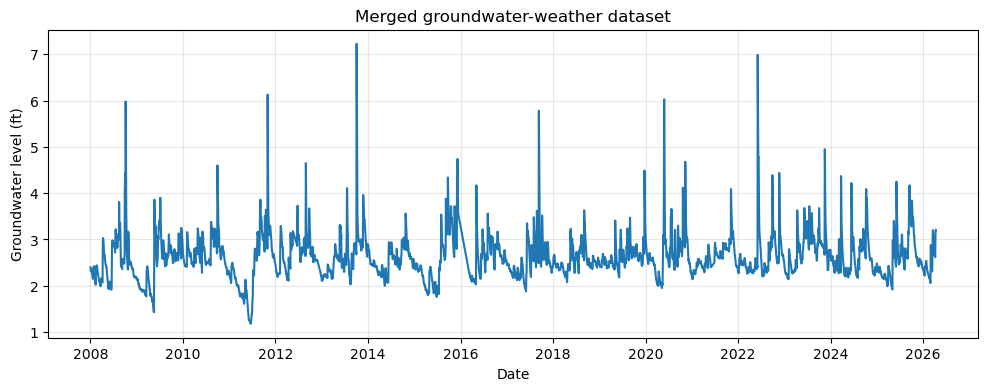

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(data["date"], data["groundwater_level_ft_ngvd29"], label="Groundwater level")
plt.title("Merged groundwater-weather dataset")
plt.xlabel("Date")
plt.ylabel("Groundwater level (ft)")
plt.grid(True, alpha=0.3)
plt.show()

## Step 1: Build tabular features for the classical models

For groundwater systems, **recent history matters a lot**.  
So we include:
- groundwater lags
- rainfall totals over short windows
- ET₀ averages over short windows

The target is **tomorrow's groundwater level**.

### Why these feature groups make hydrologic sense
- **Groundwater lags** represent aquifer memory and persistence.
- **Rolling rainfall totals** represent short-term recharge accumulation rather than only same-day rain.
- **Rolling ET₀ averages** represent recent atmospheric demand that can gradually lower shallow groundwater.
- **Seasonal sine/cosine terms** allow the model to learn broad annual patterns without manually assigning wet and dry seasons.

### Teaching note
These are still **handcrafted tabular features**.  
That is useful because students can directly see what information is being given to the model before moving to the more automated sequence-based LSTM approach.


In [20]:
# ============================================================
# 5. Feature engineering for the tabular models
# ============================================================
model_data = data.copy()

# Groundwater persistence features
model_data["gw_t"] = model_data["groundwater_level_ft_ngvd29"]
model_data["gw_t_minus_1"] = model_data["groundwater_level_ft_ngvd29"].shift(1)
model_data["gw_t_minus_2"] = model_data["groundwater_level_ft_ngvd29"].shift(2)
model_data["gw_t_minus_3"] = model_data["groundwater_level_ft_ngvd29"].shift(3)
model_data["gw_t_minus_7"] = model_data["groundwater_level_ft_ngvd29"].shift(7)
model_data["gw_ma_3"] = model_data["groundwater_level_ft_ngvd29"].rolling(window=3).mean()
model_data["gw_ma_7"] = model_data["groundwater_level_ft_ngvd29"].rolling(window=7).mean()
model_data["gw_ma_14"] = model_data["groundwater_level_ft_ngvd29"].rolling(window=14).mean()

# Rainfall features
model_data["rain_t"] = model_data["rain_mm"]
model_data["rain_t_minus_1"] = model_data["rain_mm"].shift(1)
model_data["rain_t_minus_2"] = model_data["rain_mm"].shift(2)
model_data["rain_sum_3"] = model_data["rain_mm"].rolling(window=3).sum()
model_data["rain_sum_7"] = model_data["rain_mm"].rolling(window=7).sum()
model_data["rain_sum_14"] = model_data["rain_mm"].rolling(window=14).sum()

# ET0 features
model_data["et0_t"] = model_data["et0_mm"]
model_data["et0_t_minus_1"] = model_data["et0_mm"].shift(1)
model_data["et0_t_minus_2"] = model_data["et0_mm"].shift(2)
model_data["et0_mean_3"] = model_data["et0_mm"].rolling(window=3).mean()
model_data["et0_mean_7"] = model_data["et0_mm"].rolling(window=7).mean()
model_data["et0_mean_14"] = model_data["et0_mm"].rolling(window=14).mean()

# Optional seasonality features
dayofyear = model_data["date"].dt.dayofyear
model_data["doy_sin"] = np.sin(2 * np.pi * dayofyear / 365.25)
model_data["doy_cos"] = np.cos(2 * np.pi * dayofyear / 365.25)

# Target: tomorrow's groundwater level
model_data["target_next_day_gw"] = model_data["groundwater_level_ft_ngvd29"].shift(-1)

feature_cols = [
    "gw_t",
    "gw_t_minus_1",
    "gw_t_minus_2",
    "gw_t_minus_3",
    "gw_t_minus_7",
    "gw_ma_3",
    "gw_ma_7",
    "gw_ma_14",
    "rain_t",
    "rain_t_minus_1",
    "rain_t_minus_2",
    "rain_sum_3",
    "rain_sum_7",
    "rain_sum_14",
    "et0_t",
    "et0_t_minus_1",
    "et0_t_minus_2",
    "et0_mean_3",
    "et0_mean_7",
    "et0_mean_14",
    "doy_sin",
    "doy_cos",
]

model_data = model_data.dropna().reset_index(drop=True)

print("Rows after feature engineering:", len(model_data))
display(model_data[["date"] + feature_cols + ["target_next_day_gw"]].head())

Rows after feature engineering: 6437


,date,gw_t,gw_t_minus_1,gw_t_minus_2,gw_t_minus_3,gw_t_minus_7,gw_ma_3,gw_ma_7,gw_ma_14,rain_t,...,rain_sum_14,et0_t,et0_t_minus_1,et0_t_minus_2,et0_mean_3,et0_mean_7,et0_mean_14,doy_sin,doy_cos,target_next_day_gw
0,2008-01-14,2.27,2.28,2.29,2.32,2.36,2.280000,2.317143,2.337143,0.3,...,17.9,2.71,2.51,2.85,2.690000,2.975714,3.129286,0.238513,0.971139,2.25
1,2008-01-15,2.25,2.27,2.28,2.29,2.36,2.266667,2.301429,2.326429,0.0,...,5.9,3.26,2.71,2.51,2.826667,2.937143,3.186429,0.255182,0.966893,2.22
2,2008-01-16,2.22,2.25,2.27,2.28,2.36,2.246667,2.281429,2.314286,0.0,...,5.7,3.72,3.26,2.71,3.230000,3.088571,3.107857,0.271777,0.962360,2.20
3,2008-01-17,2.20,2.22,2.25,2.27,2.34,2.223333,2.261429,2.304286,0.0,...,5.7,3.32,3.72,3.26,3.433333,3.078571,3.108571,0.288291,0.957543,2.17
4,2008-01-18,2.17,2.20,2.22,2.25,2.32,2.196667,2.240000,2.293571,0.1,...,4.8,2.84,3.32,3.72,3.293333,3.030000,3.072143,0.304719,0.952442,2.17


## Step 2: Build LSTM sequences

For the LSTM, each sample contains the previous **14 days** of:
- groundwater level
- rainfall
- ET₀

The target is still **tomorrow's groundwater level**.

### Why a 14-day window?
A two-week window is long enough to capture **short-term aquifer memory** and recent hydroclimatic forcing, but still short enough to keep the notebook simple and fast for class use.

### Teaching note
In the tabular models, we tell the model explicitly which lagged variables to use.  
In the **LSTM**, we give the model an ordered sequence and let it learn which parts of the recent history are most useful.


In [23]:
# ============================================================
# 6. Create aligned sequences for the LSTM
# ============================================================
sequence_feature_cols = ["groundwater_level_ft_ngvd29", "rain_mm", "et0_mm"]
sequence_length = 14

sequence_arrays = []
sequence_targets = []
sequence_dates = []

for end_idx in range(sequence_length - 1, len(data) - 1):
    window = data[sequence_feature_cols].iloc[end_idx - sequence_length + 1 : end_idx + 1].to_numpy(dtype=np.float32)
    target_next_day_gw = float(data["groundwater_level_ft_ngvd29"].iloc[end_idx + 1])

    sequence_arrays.append(window)
    sequence_targets.append(target_next_day_gw)
    sequence_dates.append(data["date"].iloc[end_idx])

sequence_meta = pd.DataFrame({
    "date": sequence_dates,
    "sequence_index": np.arange(len(sequence_dates)),
})

aligned = model_data[["date"]].merge(sequence_meta, on="date", how="left")
if aligned["sequence_index"].isna().any():
    raise ValueError("LSTM sequence dates did not align with the tabular feature dates.")

sequence_index = aligned["sequence_index"].astype(int).to_numpy()
X_sequences = np.stack(sequence_arrays)[sequence_index]
y_sequence_reg = np.array(sequence_targets, dtype=np.float32)[sequence_index]

a = model_data["target_next_day_gw"].to_numpy(dtype=np.float32)
if not np.allclose(a, y_sequence_reg):
    raise ValueError("Regression targets are not aligned between tabular and LSTM datasets.")

print("Sequence tensor shape:", X_sequences.shape)
print("Each sample shape   :", X_sequences.shape[1:])

Sequence tensor shape: (6437, 14, 3)
Each sample shape   : (14, 3)


## Step 3: Time-based train/test split

We keep the split **chronological** because this is a forecasting problem.

### Why this matters
A random split would mix past and future conditions together and can make the model look better than it really is.  
For water-resources forecasting, the proper question is:

> **Can the model learn from the past and predict a later period it has not yet seen?**

That is why we use a **time-based split** instead of a shuffled split.


In [26]:
# ============================================================
# 7. Time-based train/test split
# ============================================================
split_index = int(len(model_data) * 0.8)

train = model_data.iloc[:split_index].copy()
test = model_data.iloc[split_index:].copy()

X_train_reg = train[feature_cols]
X_test_reg = test[feature_cols]
y_train_reg = train["target_next_day_gw"]
y_test_reg = test["target_next_day_gw"]

X_train_seq = X_sequences[:split_index].copy()
X_test_seq = X_sequences[split_index:].copy()
y_train_seq_reg = y_sequence_reg[:split_index].copy()
y_test_seq_reg = y_sequence_reg[split_index:].copy()

print("Training period:", train["date"].min().date(), "to", train["date"].max().date())
print("Testing period :", test["date"].min().date(), "to", test["date"].max().date())
print("Training rows  :", len(train))
print("Testing rows   :", len(test))

Training period: 2008-01-14 to 2022-09-30
Testing period : 2022-10-01 to 2026-04-10
Training rows  : 5149
Testing rows   : 1288


## Step 4: Define the classification target

For classification, we define a **high-groundwater day** as a next-day groundwater level  
above the **90th percentile of the training data**.

In practice, this can be interpreted as a simple proxy for:
- unusually high water table conditions
- greater groundwater-related flooding concern

### Why use the training-data percentile?
The threshold should be defined using only the **training period**, so the model setup does not accidentally use information from the test period.

### Why the 90th percentile?
This is a simple beginner choice that creates a **rare-event style problem**:
- not every day is a high-groundwater day,
- the event is still common enough to train a classifier, and
- the threshold is easy to explain in class.


In [29]:
# ============================================================
# 8. Classification target
# ============================================================
high_gw_threshold = train["target_next_day_gw"].quantile(0.90)

y_train_class = (y_train_reg >= high_gw_threshold).astype(int)
y_test_class = (y_test_reg >= high_gw_threshold).astype(int)

y_train_seq_class = (y_train_seq_reg >= high_gw_threshold).astype(np.float32)
y_test_seq_class = (y_test_seq_reg >= high_gw_threshold).astype(np.float32)

print("High-groundwater threshold (ft NGVD29):", round(high_gw_threshold, 3))
print("Training high-groundwater fraction:", round(float(y_train_class.mean()), 3))
print("Testing high-groundwater fraction :", round(float(y_test_class.mean()), 3))

High-groundwater threshold (ft NGVD29): 3.14
Training high-groundwater fraction: 0.101
Testing high-groundwater fraction : 0.142


# Part A - Regression Task  
### Predict the next day groundwater level
The regression models estimate a **continuous groundwater elevation** for the next day.  
Later in the notebook, these same next-day models are **rolled forward recursively** to create a **7-day groundwater forecast**.

## Regression model settings: what the main parameters mean

### Linear Regression
`LinearRegression()` has almost no tuning in this notebook.  
That is useful for teaching because students can see the behavior of a simple baseline before moving to more flexible models.

### Random Forest Regressor
- `n_estimators=300`: number of trees in the forest. More trees usually stabilize the prediction, but increase run time.
- `max_depth=10`: limits how deep each tree can grow. This helps reduce overfitting.
- `random_state=42`: makes the run reproducible.
- `n_jobs=-1`: uses all available CPU cores.

### XGBoost Regressor
- `n_estimators=300`: number of boosting rounds / trees.
- `learning_rate=0.05`: each tree makes a relatively small correction, which often improves stability.
- `max_depth=4`: keeps individual trees fairly simple.
- `subsample=0.9`: uses 90% of the training rows for each boosting round to reduce overfitting.
- `colsample_bytree=0.9`: uses 90% of the predictors for each tree to reduce dependence on any single feature.
- `objective="reg:squarederror"`: tells XGBoost to solve a regression problem using squared-error loss.
- `tree_method="hist"`: a faster tree-building method appropriate for many tabular problems.
- `random_state=42`: reproducibility.

### Teaching note
The parameter values here are **not universal best settings**.  
They are reasonable, classroom-friendly values that usually work well enough to demonstrate the ideas without long tuning exercises.


In [33]:
# ============================================================
# 9. Train the tabular regression models
# ============================================================
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=1,
    ),
}

reg_predictions = {}
reg_results = []

for name, model in reg_models.items():
    model.fit(X_train_reg, y_train_reg)
    pred = model.predict(X_test_reg)
    reg_predictions[name] = pred
    reg_results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test_reg, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_reg, pred)),
        "R2": r2_score(y_test_reg, pred),
    })

reg_results_df = pd.DataFrame(reg_results)
display(reg_results_df.round(3))

,model,MAE,RMSE,R2
0,Linear Regression,0.047,0.116,0.931
1,Random Forest,0.060,0.146,0.892
2,XGBoost,0.058,0.134,0.909


## LSTM regressor settings: what is happening here

Before training the LSTM, the notebook standardizes the sequence inputs using the **training-set mean and standard deviation**.  
This helps neural networks train more smoothly because the variables are put on comparable numeric scales.

### Main LSTM training choices
- `hidden_size=32`: number of hidden units in the LSTM state. Larger values increase model flexibility.
- `Adam(lr=0.01)`: adaptive optimizer used to update weights during training.
- `MSELoss()`: the loss function for regression; it penalizes squared errors.
- `batch_size=64`: number of sequences processed before each optimizer update.
- `epochs=30`: number of passes through the training data.
- `shuffle=False`: keeps the batches in time order, which is a reasonable beginner choice for sequence forecasting.

### How to read the loss plot
The loss curve shows whether training error is generally going down.  
A steadily decreasing curve suggests the model is learning; a very noisy or flat curve may suggest the model, data, or settings need adjustment.


In [36]:
# ============================================================
# 10. Prepare and train the LSTM regressor
# ============================================================
sequence_mean = X_train_seq.reshape(-1, X_train_seq.shape[-1]).mean(axis=0)
sequence_std = X_train_seq.reshape(-1, X_train_seq.shape[-1]).std(axis=0)
sequence_std[sequence_std == 0] = 1.0

X_train_seq_scaled = (X_train_seq - sequence_mean) / sequence_std
X_test_seq_scaled = (X_test_seq - sequence_mean) / sequence_std

y_reg_mean = float(y_train_seq_reg.mean())
y_reg_std = float(y_train_seq_reg.std())
if y_reg_std == 0:
    y_reg_std = 1.0

y_train_seq_reg_scaled = (y_train_seq_reg - y_reg_mean) / y_reg_std

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=3, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)

lstm_reg = LSTMRegressor(input_size=X_train_seq.shape[-1], hidden_size=32)
optimizer = torch.optim.Adam(lstm_reg.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

train_loader_reg = DataLoader(
    TensorDataset(
        torch.tensor(X_train_seq_scaled, dtype=torch.float32),
        torch.tensor(y_train_seq_reg_scaled, dtype=torch.float32),
    ),
    batch_size=64,
    shuffle=False,
)

lstm_reg_loss_history = []
for epoch in range(30):
    epoch_losses = []
    for xb, yb in train_loader_reg:
        optimizer.zero_grad()
        pred = lstm_reg(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    lstm_reg_loss_history.append(float(np.mean(epoch_losses)))

with torch.no_grad():
    lstm_reg_pred_scaled = lstm_reg(torch.tensor(X_test_seq_scaled, dtype=torch.float32)).numpy()

lstm_reg_pred = lstm_reg_pred_scaled * y_reg_std + y_reg_mean

reg_predictions["LSTM"] = lstm_reg_pred
reg_results_df = pd.concat([
    reg_results_df,
    pd.DataFrame([{
        "model": "LSTM",
        "MAE": mean_absolute_error(y_test_seq_reg, lstm_reg_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_seq_reg, lstm_reg_pred)),
        "R2": r2_score(y_test_seq_reg, lstm_reg_pred),
    }]),
], ignore_index=True)

display(reg_results_df.round(3))

,model,MAE,RMSE,R2
0,Linear Regression,0.047,0.116,0.931
1,Random Forest,0.060,0.146,0.892
2,XGBoost,0.058,0.134,0.909
3,LSTM,0.057,0.133,0.910


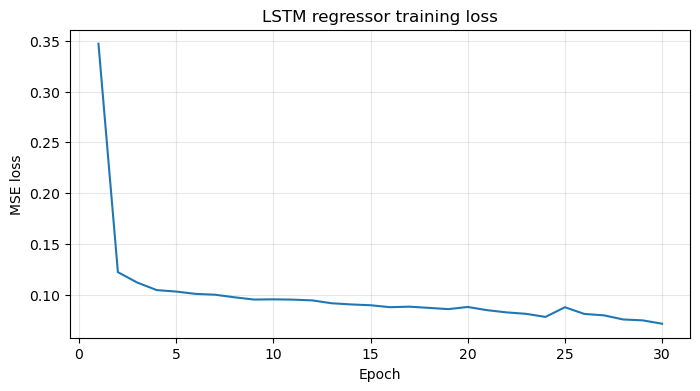

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(lstm_reg_loss_history) + 1), lstm_reg_loss_history)
plt.title("LSTM regressor training loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.grid(True, alpha=0.3)
plt.show()

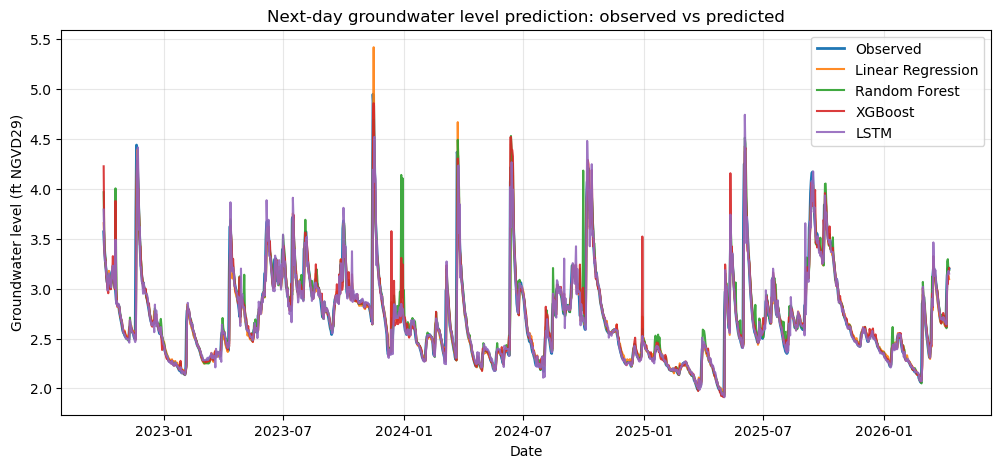

In [40]:
# Plot observed vs predicted groundwater level for the test period
plt.figure(figsize=(12, 5))
plt.plot(test["date"], y_test_reg.values, label="Observed", linewidth=2)

for name, pred in reg_predictions.items():
    plt.plot(test["date"], pred, label=name, alpha=0.9)

plt.title("Next-day groundwater level prediction: observed vs predicted")
plt.xlabel("Date")
plt.ylabel("Groundwater level (ft NGVD29)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## How to read feature importance and coefficient outputs for regression

This notebook shows both **tables** and **plots** for the tabular regression models.

### Linear Regression coefficients
The sign matters:
- a **positive** coefficient means the prediction tends to increase as that predictor increases,
- a **negative** coefficient means the prediction tends to decrease.

However, coefficient magnitude should be interpreted carefully because the predictors are **not all on the same scale**.

### Tree-model feature importance
For **Random Forest** and **XGBoost**, larger importance values mean the model relied more on that predictor when making splits and reducing error.

### Physical interpretation
If groundwater lags dominate the importance ranking, that supports the hydrologic idea of **aquifer memory / persistence**.  
If rainfall totals and ET₀ windows also appear high in the ranking, that shows the model is using both **recharge** and **atmospheric demand** information.


,feature,Linear Regression coefficient,abs_coefficient
9,rain_t_minus_1,-2.053215e+09,2.053215e+09
11,rain_sum_3,2.053215e+09,2.053215e+09
10,rain_t_minus_2,-2.053215e+09,2.053215e+09
8,rain_t,-2.053215e+09,2.053215e+09
5,gw_ma_3,-2.226676e+07,2.226676e+07
17,et0_mean_3,-7.793978e+06,7.793978e+06
0,gw_t,7.422255e+06,7.422255e+06
2,gw_t_minus_2,7.422254e+06,7.422254e+06
1,gw_t_minus_1,7.422254e+06,7.422254e+06
15,et0_t_minus_1,2.597993e+06,2.597993e+06


,feature,Random Forest importance
0,gw_t,0.9107
14,et0_t,0.0143
8,rain_t,0.0105
20,doy_sin,0.0093
1,gw_t_minus_1,0.0078
2,gw_t_minus_2,0.0050
7,gw_ma_14,0.0042
19,et0_mean_14,0.0041
11,rain_sum_3,0.0040
5,gw_ma_3,0.0034


,feature,XGBoost importance
0,gw_t,0.4653
5,gw_ma_3,0.2792
1,gw_t_minus_1,0.0532
9,rain_t_minus_1,0.0217
8,rain_t,0.0211
11,rain_sum_3,0.0209
14,et0_t,0.0188
7,gw_ma_14,0.0147
2,gw_t_minus_2,0.0142
20,doy_sin,0.0100


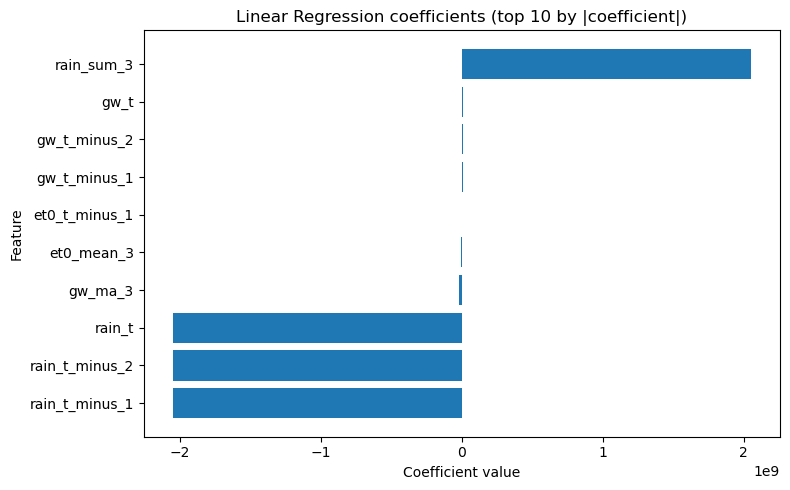

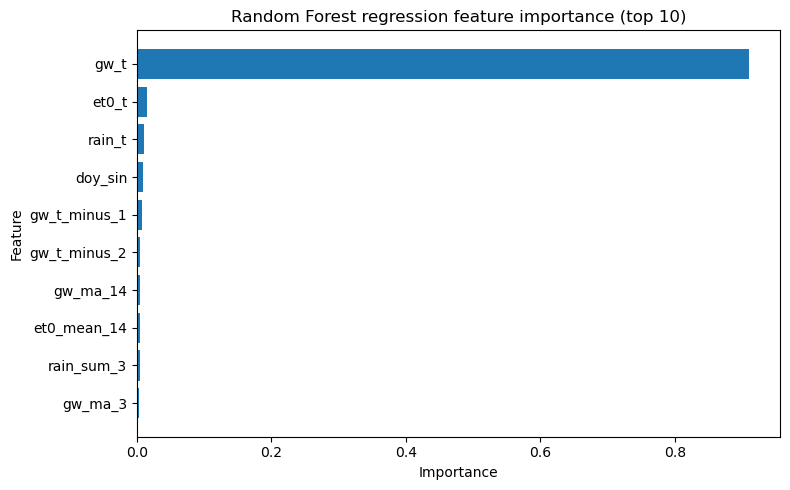

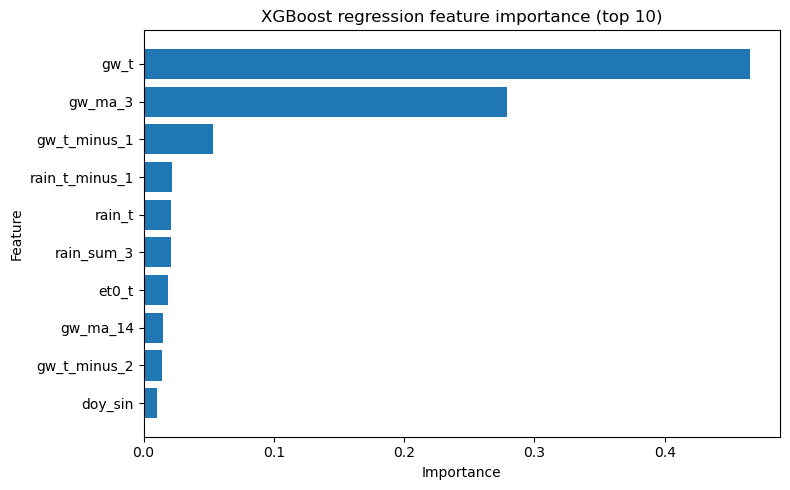

In [43]:
# Coefficients / feature importances for the tabular regression models
importance_tables = []

lin_model = reg_models["Linear Regression"]
rf_model = reg_models["Random Forest"]
xgb_model = reg_models["XGBoost"]

lin_table = pd.DataFrame({
    "feature": feature_cols,
    "Linear Regression coefficient": lin_model.coef_,
})
lin_table["abs_coefficient"] = lin_table["Linear Regression coefficient"].abs()
lin_table = lin_table.sort_values("abs_coefficient", ascending=False)

rf_table = pd.DataFrame({
    "feature": feature_cols,
    "Random Forest importance": rf_model.feature_importances_,
}).sort_values("Random Forest importance", ascending=False)

xgb_table = pd.DataFrame({
    "feature": feature_cols,
    "XGBoost importance": xgb_model.feature_importances_,
}).sort_values("XGBoost importance", ascending=False)

importance_tables.extend([lin_table, rf_table, xgb_table])

for table in importance_tables:
    display(table.head(10).round(4))

# --- Feature importance plots ---
top_n = 10

# Linear Regression: plot signed coefficients for the largest absolute values
lin_plot = lin_table.head(top_n).sort_values("Linear Regression coefficient")
plt.figure(figsize=(8, 5))
plt.barh(lin_plot["feature"], lin_plot["Linear Regression coefficient"])
plt.title("Linear Regression coefficients (top 10 by |coefficient|)")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Random Forest
rf_plot = rf_table.head(top_n).sort_values("Random Forest importance")
plt.figure(figsize=(8, 5))
plt.barh(rf_plot["feature"], rf_plot["Random Forest importance"])
plt.title("Random Forest regression feature importance (top 10)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# XGBoost
xgb_plot = xgb_table.head(top_n).sort_values("XGBoost importance")
plt.figure(figsize=(8, 5))
plt.barh(xgb_plot["feature"], xgb_plot["XGBoost importance"])
plt.title("XGBoost regression feature importance (top 10)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### Beginner interpretation of the regression comparison

- **Linear Regression** gives a simple baseline and is easy to explain.
- **Random Forest** can capture non-linear behavior without much tuning.
- **XGBoost** often performs well when there are non-linear thresholds and interactions.
- **LSTM** uses the full recent time sequence, which can help when system memory matters.

For groundwater, the most important idea is usually **persistence**:  
today's groundwater level is often one of the strongest clues about tomorrow's level.

### How to read the regression output statistics
- A **lower MAE** means the average absolute groundwater error is smaller.
- A **lower RMSE** means large misses are less common.
- A **higher R²** means the model is explaining more of the day-to-day variation.

If two models have similar scores, the simpler model may still be attractive for teaching, communication, and reproducibility.


## SHAP interpretation for the XGBoost regression model

**SHAP** (SHapley Additive exPlanations) explains each prediction by splitting it into feature contributions.

For the groundwater **regression** model:
- a **positive SHAP value** means that feature pushes the predicted groundwater level **up**
- a **negative SHAP value** means that feature pushes the prediction **down**
- the **mean absolute SHAP value** is a global importance score across many samples

Why add SHAP if we already plotted built-in feature importance?
- built-in tree importance tells us **which features the model used often**
- SHAP helps explain **how much** each feature changed predictions and in **which direction**

Below, the notebook uses the **XGBoost regressor** because tree-based models work very well with `shap.TreeExplainer` and are fast enough for classroom demonstrations.

,feature,mean_abs_SHAP
0,gw_t,0.2886
1,gw_t_minus_1,0.0631
5,gw_ma_3,0.0401
8,rain_t,0.0339
2,gw_t_minus_2,0.0158
20,doy_sin,0.0114
14,et0_t,0.0112
9,rain_t_minus_1,0.0080
4,gw_t_minus_7,0.0078
11,rain_sum_3,0.0059


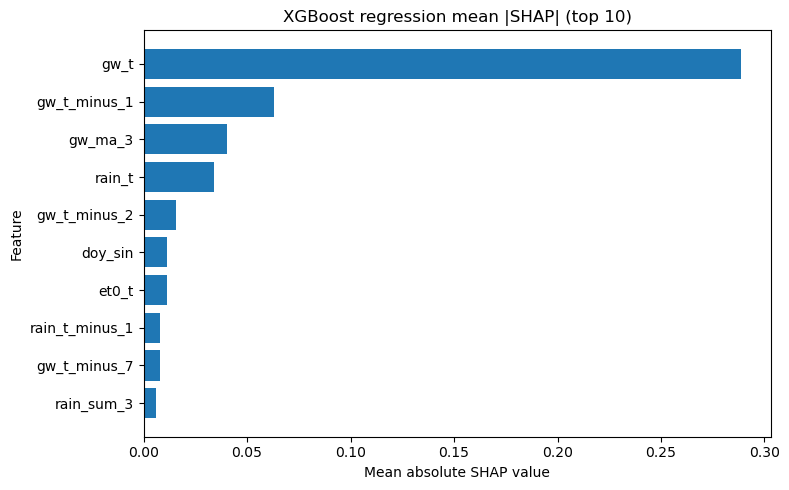

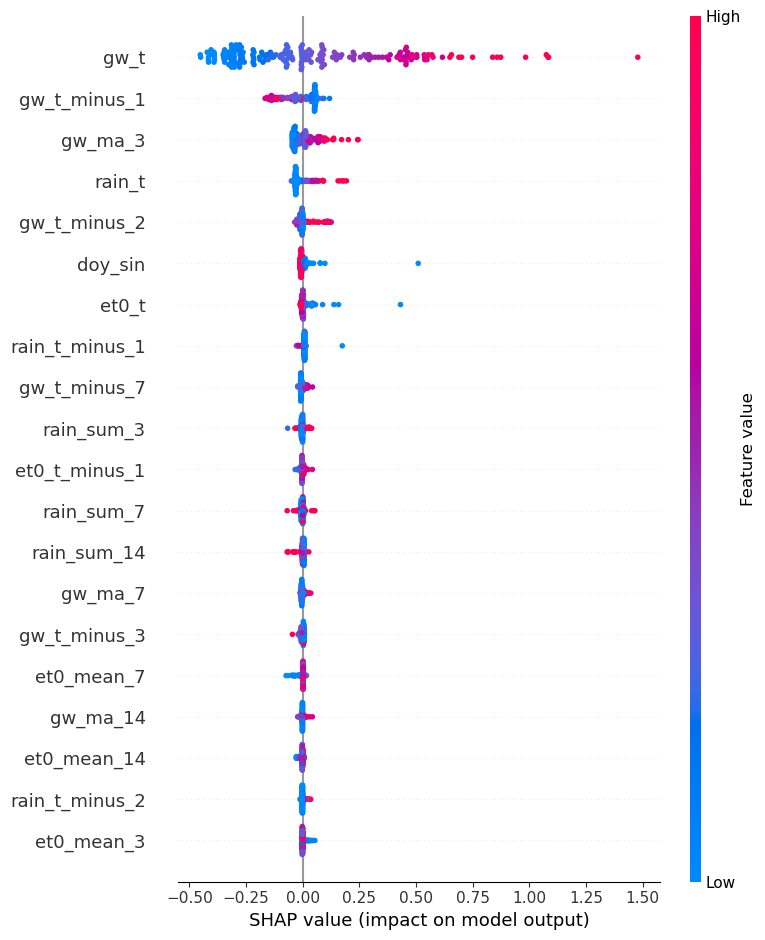

In [47]:
# SHAP interpretation for the XGBoost regressor

def _select_shap_array(shap_values):
    # Return a 2D SHAP array with shape (n_samples, n_features).
    if isinstance(shap_values, list):
        return np.array(shap_values[-1])

    arr = np.array(shap_values)
    if arr.ndim == 3:
        if arr.shape[-1] == 2:   # (n_samples, n_features, n_classes)
            return arr[:, :, 1]
        if arr.shape[0] == 2:    # (n_classes, n_samples, n_features)
            return arr[1]
    return arr

reg_train_df = pd.DataFrame(X_train_reg, columns=feature_cols)
reg_test_df = pd.DataFrame(X_test_reg, columns=feature_cols)

background_reg = reg_train_df.sample(n=min(200, len(reg_train_df)), random_state=RANDOM_STATE)
explain_reg = reg_test_df.iloc[:min(200, len(reg_test_df))].copy()

xgb_reg_model = reg_models["XGBoost"]
reg_explainer = shap.TreeExplainer(
    xgb_reg_model,
    data=background_reg,
    feature_perturbation="interventional",
)
reg_shap_values = _select_shap_array(reg_explainer.shap_values(explain_reg))

reg_shap_table = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_SHAP": np.abs(reg_shap_values).mean(axis=0),
}).sort_values("mean_abs_SHAP", ascending=False)

display(reg_shap_table.head(10).round(4))

plt.figure(figsize=(8, 5))
plot_df = reg_shap_table.head(10).sort_values("mean_abs_SHAP")
plt.barh(plot_df["feature"], plot_df["mean_abs_SHAP"])
plt.title("XGBoost regression mean |SHAP| (top 10)")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

shap.summary_plot(reg_shap_values, explain_reg, show=False)
plt.show()

# Part B - Classification Task  
### Predict whether tomorrow is a high-groundwater day

The classification models estimate whether the next day crosses the **high-groundwater threshold** defined earlier.

### Classification metrics used in this notebook
- **Accuracy:** fraction of all predictions that are correct.
- **Precision:** among predicted high-groundwater days, how many were actually high.
- **Recall:** among actual high-groundwater days, how many the model found.
- **F1:** balance between precision and recall.
- **ROC-AUC:** how well the model separates high vs. non-high days over many thresholds.

### Practical interpretation
In rare-event hydrology problems, **accuracy alone can be misleading**.  
That is why the notebook also reports **precision, recall, F1, and ROC-AUC**.


## Classification model settings: what the main parameters mean

Because the high-groundwater class is relatively rare, this is an **imbalanced classification problem**.

### Class-balance helper
`scale_pos_weight = n_neg / n_pos`

This gives XGBoost a larger penalty for missing the positive class when high-groundwater days are less common than normal days.

### Logistic Regression
- `max_iter=2000`: allows enough optimization iterations for convergence.

### Random Forest Classifier
- `n_estimators=300`: number of trees.
- `max_depth=10`: helps control overfitting.
- `random_state=42`: reproducibility.
- `n_jobs=-1`: parallel processing across CPU cores.

### XGBoost Classifier
- `n_estimators=300`: number of boosting rounds.
- `learning_rate=0.05`: smaller step size per round.
- `max_depth=4`: keeps trees moderately simple.
- `subsample=0.9` and `colsample_bytree=0.9`: regularization through row and feature subsampling.
- `eval_metric="logloss"`: classification loss used during fitting.
- `scale_pos_weight=...`: compensates for class imbalance.
- `tree_method="hist"`: efficient tree construction.
- `random_state=42`: reproducibility.

### How to read the classification table
For rare-event problems, a model with high **recall** may be preferred if missing a true event is costly, while a model with high **precision** may be preferred if false alarms are costly.


In [51]:
# ============================================================
# 11. Train the tabular classification models
# ============================================================
n_pos = int(y_train_class.sum())
n_neg = int((1 - y_train_class).sum())
scale_pos_weight = n_neg / max(n_pos, 1)

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        n_jobs=1,
    ),
}

clf_predictions = {}
clf_probabilities = {}
clf_results = []

for name, model in clf_models.items():
    model.fit(X_train_reg, y_train_class)
    pred = model.predict(X_test_reg)
    prob = model.predict_proba(X_test_reg)[:, 1]

    clf_predictions[name] = pred
    clf_probabilities[name] = prob

    clf_results.append({
        "model": name,
        "Accuracy": accuracy_score(y_test_class, pred),
        "Precision": precision_score(y_test_class, pred, zero_division=0),
        "Recall": recall_score(y_test_class, pred, zero_division=0),
        "F1": f1_score(y_test_class, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test_class, prob),
    })

clf_results_df = pd.DataFrame(clf_results)
display(clf_results_df.round(3))

,model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.968,0.944,0.825,0.880,0.984
1,Random Forest,0.977,0.953,0.885,0.918,0.982
2,XGBoost,0.972,0.906,0.896,0.901,0.983


## LSTM classifier settings and probability interpretation

The LSTM classifier uses the same sequence inputs as the LSTM regressor, but now the target is binary:  
**1 = high-groundwater day**, **0 = not a high-groundwater day**.

### Main training choices
- `hidden_size=32`: size of the recurrent hidden state.
- `Adam(lr=0.01)`: optimizer.
- `BCEWithLogitsLoss(...)`: binary cross-entropy loss applied to raw model logits.
- `pos_weight=scale_pos_weight`: increases the penalty for missing positive events.
- `batch_size=64`: mini-batch size.
- `epochs=25`: number of passes through the training set.

### Why use sigmoid after training?
The raw LSTM output is a **logit**, not yet a probability.  
Applying the sigmoid function converts it to a value between 0 and 1, which we interpret as the estimated probability of a high-groundwater day.

### Why threshold at 0.5?
This is the simplest beginner threshold.  
In real warning applications, a different threshold might be chosen to favor either higher recall or lower false alarms.


In [54]:
# ============================================================
# 12. Train the LSTM classifier
# ============================================================
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=3, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)

lstm_clf = LSTMClassifier(input_size=X_train_seq.shape[-1], hidden_size=32)
optimizer = torch.optim.Adam(lstm_clf.parameters(), lr=0.01)
pos_weight_tensor = torch.tensor([scale_pos_weight], dtype=torch.float32)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

train_loader_clf = DataLoader(
    TensorDataset(
        torch.tensor(X_train_seq_scaled, dtype=torch.float32),
        torch.tensor(y_train_seq_class, dtype=torch.float32),
    ),
    batch_size=64,
    shuffle=False,
)

lstm_clf_loss_history = []
for epoch in range(25):
    epoch_losses = []
    for xb, yb in train_loader_clf:
        optimizer.zero_grad()
        logits = lstm_clf(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    lstm_clf_loss_history.append(float(np.mean(epoch_losses)))

with torch.no_grad():
    lstm_logits = lstm_clf(torch.tensor(X_test_seq_scaled, dtype=torch.float32))
    lstm_prob = torch.sigmoid(lstm_logits).numpy()

lstm_pred = (lstm_prob >= 0.5).astype(int)

clf_predictions["LSTM"] = lstm_pred
clf_probabilities["LSTM"] = lstm_prob
clf_results_df = pd.concat([
    clf_results_df,
    pd.DataFrame([{
        "model": "LSTM",
        "Accuracy": accuracy_score(y_test_seq_class, lstm_pred),
        "Precision": precision_score(y_test_seq_class, lstm_pred, zero_division=0),
        "Recall": recall_score(y_test_seq_class, lstm_pred, zero_division=0),
        "F1": f1_score(y_test_seq_class, lstm_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test_seq_class, lstm_prob),
    }]),
], ignore_index=True)

display(clf_results_df.round(3))

,model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.968,0.944,0.825,0.880,0.984
1,Random Forest,0.977,0.953,0.885,0.918,0.982
2,XGBoost,0.972,0.906,0.896,0.901,0.983
3,LSTM,0.954,0.787,0.929,0.852,0.984


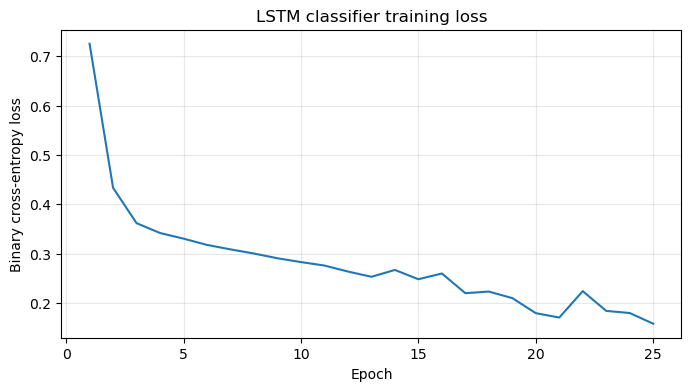

In [55]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(lstm_clf_loss_history) + 1), lstm_clf_loss_history)
plt.title("LSTM classifier training loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.grid(True, alpha=0.3)
plt.show()

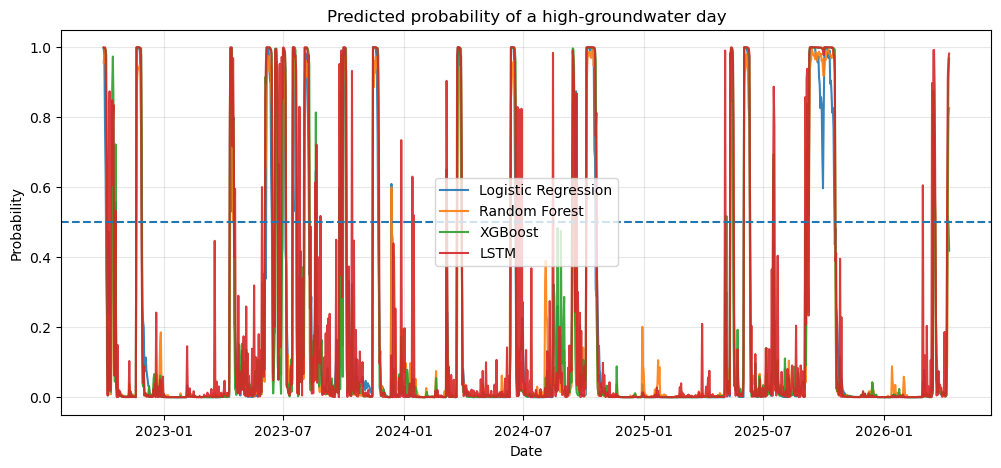

In [58]:
# Probability plot for the test period
plt.figure(figsize=(12, 5))
for name, prob in clf_probabilities.items():
    plt.plot(test["date"], prob, label=name, alpha=0.9)

plt.axhline(0.5, linestyle="--")
plt.title("Predicted probability of a high-groundwater day")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Reading the confusion matrices

Each confusion matrix separates the test predictions into four groups:

- **True Positive (TP):** predicted high and actually high
- **False Positive (FP):** predicted high but actually not high
- **True Negative (TN):** predicted not high and actually not high
- **False Negative (FN):** predicted not high but actually high

### Water-resources interpretation
- High **FN** can be a concern if the goal is to avoid missing potentially problematic high-water-table days.
- High **FP** can be a concern if the goal is to reduce unnecessary warnings or operational responses.


In [61]:
# Confusion matrices
for name, pred in clf_predictions.items():
    cm = confusion_matrix(y_test_class, pred)
    print("\n", name)
    print(pd.DataFrame(
        cm,
        index=["Observed low", "Observed high"],
        columns=["Predicted low", "Predicted high"],
    ))


 Logistic Regression
               Predicted low  Predicted high
Observed low            1096               9
Observed high             32             151

 Random Forest
               Predicted low  Predicted high
Observed low            1097               8
Observed high             21             162

 XGBoost
               Predicted low  Predicted high
Observed low            1088              17
Observed high             19             164

 LSTM
               Predicted low  Predicted high
Observed low            1059              46
Observed high             13             170


## How to read feature importance and coefficient outputs for classification

The classification importance plots answer a slightly different question than the regression plots:

> Which predictors help the model separate **high-groundwater days** from **non-high-groundwater days**?

### Logistic Regression coefficients
The sign still indicates direction of association with the high-groundwater class, but magnitudes should again be interpreted cautiously because predictors have different scales.

### Tree-model importances
For **Random Forest** and **XGBoost**, higher importance suggests the predictor was more useful in splitting the data into high and non-high groundwater conditions.

### Hydrologic expectation
If recent groundwater conditions dominate again, that suggests the event classification is still largely controlled by **system memory**.  
If rainfall windows move up in rank, that suggests recent recharge is helping distinguish high-water-table days.


,feature,Logistic Regression coefficient,abs_coefficient
0,gw_t,8.5026,8.5026
5,gw_ma_3,2.5618,2.5618
3,gw_t_minus_3,-0.7113,0.7113
2,gw_t_minus_2,-0.4947,0.4947
6,gw_ma_7,0.4906,0.4906
14,et0_t,-0.3940,0.3940
1,gw_t_minus_1,-0.3225,0.3225
18,et0_mean_7,0.2911,0.2911
7,gw_ma_14,-0.2464,0.2464
15,et0_t_minus_1,0.2409,0.2409


,feature,Random Forest importance
0,gw_t,0.3006
5,gw_ma_3,0.1737
1,gw_t_minus_1,0.1351
2,gw_t_minus_2,0.0860
6,gw_ma_7,0.0517
3,gw_t_minus_3,0.0457
7,gw_ma_14,0.0287
12,rain_sum_7,0.0203
11,rain_sum_3,0.0173
8,rain_t,0.0170


,feature,XGBoost importance
0,gw_t,0.3258
5,gw_ma_3,0.1775
8,rain_t,0.0721
1,gw_t_minus_1,0.0511
14,et0_t,0.0341
11,rain_sum_3,0.0297
6,gw_ma_7,0.0270
16,et0_t_minus_2,0.0239
2,gw_t_minus_2,0.0238
20,doy_sin,0.0230


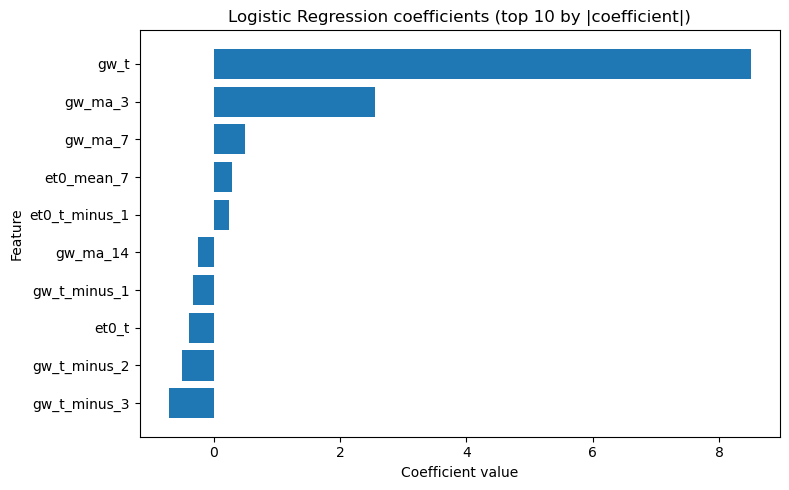

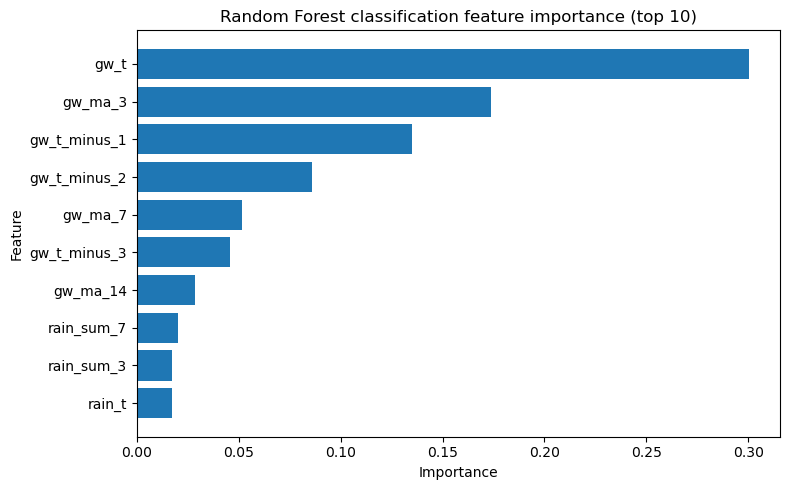

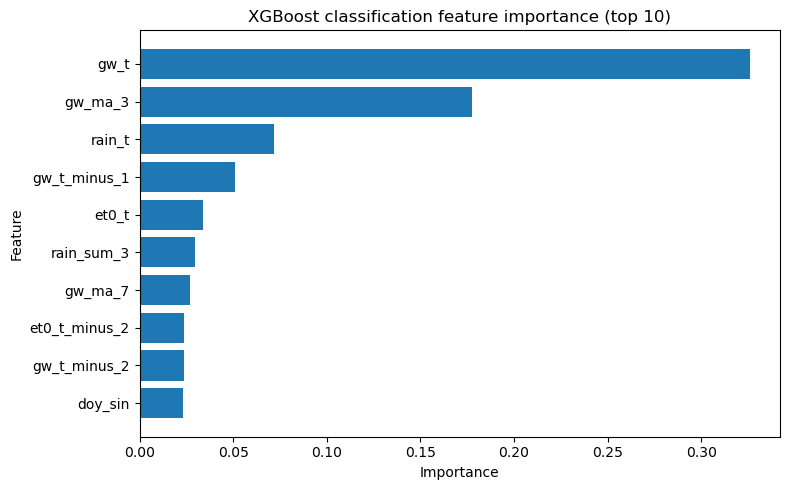

In [64]:
# Coefficients / feature importances for the tabular classification models
importance_tables_clf = []

log_model = clf_models["Logistic Regression"]
rf_clf = clf_models["Random Forest"]
xgb_clf = clf_models["XGBoost"]

log_table = pd.DataFrame({
    "feature": feature_cols,
    "Logistic Regression coefficient": log_model.coef_[0],
})
log_table["abs_coefficient"] = log_table["Logistic Regression coefficient"].abs()
log_table = log_table.sort_values("abs_coefficient", ascending=False)

rf_clf_table = pd.DataFrame({
    "feature": feature_cols,
    "Random Forest importance": rf_clf.feature_importances_,
}).sort_values("Random Forest importance", ascending=False)

xgb_clf_table = pd.DataFrame({
    "feature": feature_cols,
    "XGBoost importance": xgb_clf.feature_importances_,
}).sort_values("XGBoost importance", ascending=False)

importance_tables_clf.extend([log_table, rf_clf_table, xgb_clf_table])

for table in importance_tables_clf:
    display(table.head(10).round(4))

# --- Feature importance plots ---
top_n = 10

# Logistic Regression: plot signed coefficients for the largest absolute values
log_plot = log_table.head(top_n).sort_values("Logistic Regression coefficient")
plt.figure(figsize=(8, 5))
plt.barh(log_plot["feature"], log_plot["Logistic Regression coefficient"])
plt.title("Logistic Regression coefficients (top 10 by |coefficient|)")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Random Forest
rf_clf_plot = rf_clf_table.head(top_n).sort_values("Random Forest importance")
plt.figure(figsize=(8, 5))
plt.barh(rf_clf_plot["feature"], rf_clf_plot["Random Forest importance"])
plt.title("Random Forest classification feature importance (top 10)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# XGBoost
xgb_clf_plot = xgb_clf_table.head(top_n).sort_values("XGBoost importance")
plt.figure(figsize=(8, 5))
plt.barh(xgb_clf_plot["feature"], xgb_clf_plot["XGBoost importance"])
plt.title("XGBoost classification feature importance (top 10)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## SHAP interpretation for the XGBoost classification model

For the groundwater **classification** model, SHAP answers a slightly different question:
**which features push the model toward or away from the 'high-groundwater tomorrow' class?**

Interpretation tips:
- **positive SHAP values** push the prediction toward the **high-groundwater** class
- **negative SHAP values** push it away from that class
- the SHAP values for tree classifiers are often in **log-odds units**, so the sign and relative size are usually more useful than the raw numeric magnitude

The bar plot below summarizes **overall importance**, while the SHAP summary plot shows both:
- whether a feature usually increases or decreases the chance of a high-groundwater day
- how variable that effect is across different test cases

,feature,mean_abs_SHAP
0,gw_t,2.1618
5,gw_ma_3,0.4371
8,rain_t,0.3806
14,et0_t,0.2881
21,doy_cos,0.2645
1,gw_t_minus_1,0.2506
11,rain_sum_3,0.2256
15,et0_t_minus_1,0.2101
4,gw_t_minus_7,0.1648
20,doy_sin,0.1644


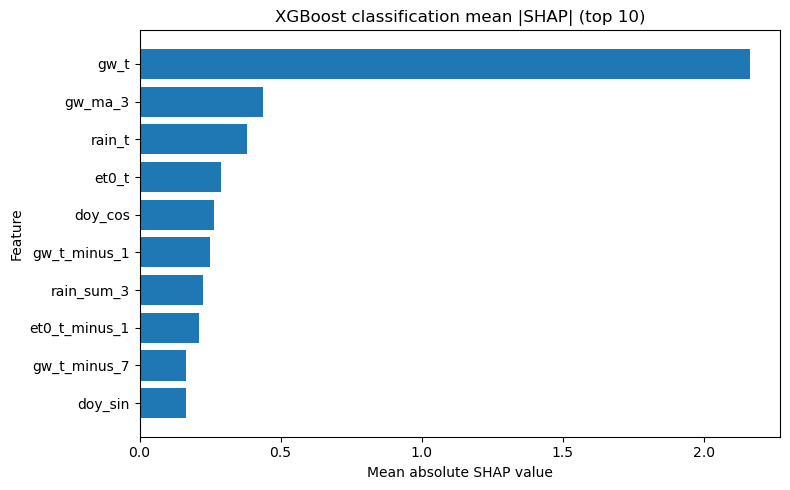

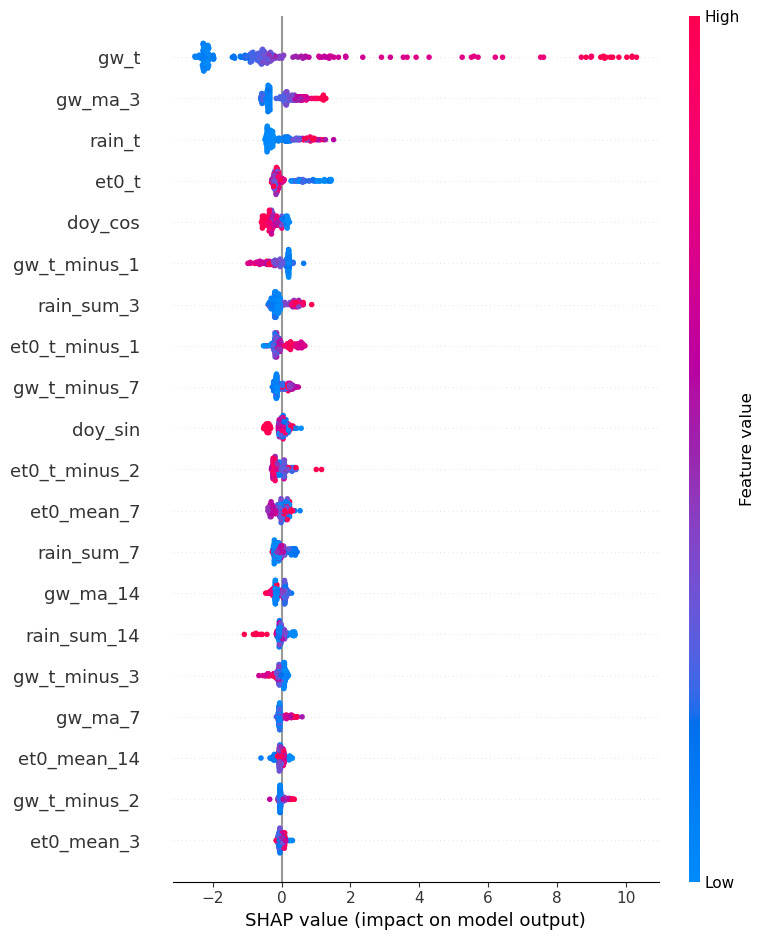

In [67]:
# SHAP interpretation for the XGBoost classifier
clf_train_df = pd.DataFrame(X_train_reg, columns=feature_cols)
clf_test_df = pd.DataFrame(X_test_reg, columns=feature_cols)

background_clf = clf_train_df.sample(n=min(200, len(clf_train_df)), random_state=RANDOM_STATE)
explain_clf = clf_test_df.iloc[:min(200, len(clf_test_df))].copy()

xgb_clf_model = clf_models["XGBoost"]
clf_explainer = shap.TreeExplainer(
    xgb_clf_model,
    data=background_clf,
    feature_perturbation="interventional",
)
clf_shap_values = _select_shap_array(clf_explainer.shap_values(explain_clf))

clf_shap_table = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_SHAP": np.abs(clf_shap_values).mean(axis=0),
}).sort_values("mean_abs_SHAP", ascending=False)

display(clf_shap_table.head(10).round(4))

plt.figure(figsize=(8, 5))
plot_df = clf_shap_table.head(10).sort_values("mean_abs_SHAP")
plt.barh(plot_df["feature"], plot_df["mean_abs_SHAP"])
plt.title("XGBoost classification mean |SHAP| (top 10)")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

shap.summary_plot(clf_shap_values, explain_clf, show=False)
plt.show()

## Combined beginner summary: how the method families compare

### Linear / Logistic Regression
- easiest to explain
- fastest to train
- good baseline
- assume relatively simple relationships

### Random Forest
- captures non-linearity
- handles interactions automatically
- usually robust with limited tuning

### XGBoost
- often very strong predictive performance
- can model complex non-linear responses
- requires a bit more tuning and interpretation care

### LSTM
- best when the **sequence itself** matters
- useful when the system has **memory**
- harder to explain and tune than the other methods

For groundwater, the key physical idea is that the aquifer has **storage and memory**.  
That is exactly why comparing a tabular model with an LSTM is interesting.

### One more teaching message
A model that is mathematically more advanced is **not automatically** the best model for a class, an agency workflow, or an operational setting.  
Sometimes the best choice is the one that gives a good balance of:
- accuracy,
- interpretability,
- training speed, and
- ease of maintenance.


## How to use the final comparison tables in class

A useful teaching sequence is:

1. Start with the **simple baselines** (Linear or Logistic Regression).
2. Compare them against the **tree models** to show how non-linearity can help.
3. Then discuss whether the **LSTM** gained anything from seeing the full recent sequence.

This helps students learn that model comparison is not only about "which score is best," but also about **why** one method may outperform another for a shallow coastal aquifer system.


In [71]:
print("Regression model comparison")
display(reg_results_df.sort_values("RMSE").reset_index(drop=True).round(3))

print("Classification model comparison")
display(clf_results_df.sort_values("ROC_AUC", ascending=False).reset_index(drop=True).round(3))

Regression model comparison


,model,MAE,RMSE,R2
0,Linear Regression,0.047,0.116,0.931
1,LSTM,0.057,0.133,0.910
2,XGBoost,0.058,0.134,0.909
3,Random Forest,0.060,0.146,0.892


Classification model comparison


,model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.968,0.944,0.825,0.880,0.984
1,LSTM,0.954,0.787,0.929,0.852,0.984
2,XGBoost,0.972,0.906,0.896,0.901,0.983
3,Random Forest,0.977,0.953,0.885,0.918,0.982


# Part C - Seven-day groundwater forecast

## Use the one-day models as an operational 7-day forecast tool
A common engineering workflow is to train a **next-day predictor** and then apply it **recursively** to obtain a short forecast horizon.  

Here, the notebook:
- refits the regression models on **all available historical data**,
- builds a **7-day rainfall and ET₀ input series** for the coming week,
- predicts groundwater one day at a time, and
- appends each new prediction back into the model input history.

This is not the same as training a direct day-7 model. Instead, it is a practical **rolling forecast** that is easy to explain in a workshop.

In [74]:
# ============================================================
# 13. Build weather inputs for the next 7 days
# ============================================================
def build_future_weather_inputs(history_df, horizon_days, site_lat, site_lon, timezone_name):
    last_observed_date = pd.to_datetime(history_df["date"].max()).normalize()
    future_dates = pd.date_range(last_observed_date + pd.Timedelta(days=1), periods=horizon_days, freq="D")

    # Fallback: repeat the most recent 7-day weather pattern if forecast download is not available.
    recent_rain = history_df["rain_mm"].tail(min(7, len(history_df))).to_numpy(dtype=float)
    recent_et0 = history_df["et0_mm"].tail(min(7, len(history_df))).to_numpy(dtype=float)

    if len(recent_rain) == 0 or len(recent_et0) == 0:
        raise ValueError("The historical weather series is empty. Cannot build forecast inputs.")

    fallback = pd.DataFrame({
        "date": future_dates,
        "rain_mm": np.resize(recent_rain, horizon_days),
        "et0_mm": np.resize(recent_et0, horizon_days),
        "weather_source": "Fallback: repeated recent 7-day pattern",
    })

    # Try to use the live Open-Meteo forecast when the groundwater record is current enough.
    today_local = pd.Timestamp.today().normalize()
    days_behind = int((today_local - last_observed_date).days)

    if days_behind > 10:
        print(
            f"Historical record ends {days_behind} days before today, so a live weather forecast is not aligned. "
            "Using fallback weather inputs instead."
        )
        return fallback

    forecast_url = (
        "https://api.open-meteo.com/v1/forecast"
        f"?latitude={site_lat}"
        f"&longitude={site_lon}"
        "&daily=precipitation_sum,et0_fao_evapotranspiration"
        f"&timezone={timezone_name.replace('/', '%2F')}"
        f"&forecast_days={horizon_days}"
    )

    try:
        with urllib.request.urlopen(forecast_url) as response:
            payload = json.loads(response.read().decode("utf-8"))

        daily = payload.get("daily", None)
        if daily is None:
            raise ValueError("Open-Meteo forecast response did not contain a 'daily' block.")

        df_future = pd.DataFrame({
            "date": pd.to_datetime(daily["time"]),
            "rain_mm": pd.to_numeric(daily["precipitation_sum"], errors="coerce"),
            "et0_mm": pd.to_numeric(daily["et0_fao_evapotranspiration"], errors="coerce"),
        }).dropna()

        if len(df_future) < horizon_days:
            raise ValueError("Forecast response did not include the full requested horizon.")

        df_future = df_future.iloc[:horizon_days].copy()
        df_future["weather_source"] = "Open-Meteo daily forecast"
        return df_future

    except Exception as exc:
        print("Live weather forecast unavailable. Falling back to repeated recent weather pattern.")
        print("Reason:", exc)
        return fallback

future_weather = build_future_weather_inputs(
    history_df=data,
    horizon_days=FORECAST_HORIZON_DAYS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    timezone_name=TIMEZONE,
)

print("Future weather inputs used for recursive forecasting")
display(future_weather.round(3))

Future weather inputs used for recursive forecasting


,date,rain_mm,et0_mm,weather_source
0,2026-04-12,0.0,5.15,Open-Meteo daily forecast
1,2026-04-13,0.0,5.37,Open-Meteo daily forecast
2,2026-04-14,0.2,6.66,Open-Meteo daily forecast
3,2026-04-15,0.0,5.57,Open-Meteo daily forecast
4,2026-04-16,0.0,6.08,Open-Meteo daily forecast
5,2026-04-17,0.0,5.86,Open-Meteo daily forecast
6,2026-04-18,0.0,5.93,Open-Meteo daily forecast


In [76]:
# ============================================================
# 14. Refit the regression models on all available history
# ============================================================
X_full_reg = model_data[feature_cols].copy()
y_full_reg = model_data["target_next_day_gw"].copy()

forecast_reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=1,
    ),
}

for name, model in forecast_reg_models.items():
    model.fit(X_full_reg, y_full_reg)

# Refit the LSTM regressor on all sequences so the final forecast uses the full history.
X_full_seq = X_sequences.copy()
y_full_seq_reg = y_sequence_reg.copy()

full_sequence_mean = X_full_seq.reshape(-1, X_full_seq.shape[-1]).mean(axis=0)
full_sequence_std = X_full_seq.reshape(-1, X_full_seq.shape[-1]).std(axis=0)
full_sequence_std[full_sequence_std == 0] = 1.0

X_full_seq_scaled = (X_full_seq - full_sequence_mean) / full_sequence_std

y_full_reg_mean = float(y_full_seq_reg.mean())
y_full_reg_std = float(y_full_seq_reg.std())
if y_full_reg_std == 0:
    y_full_reg_std = 1.0

y_full_seq_reg_scaled = (y_full_seq_reg - y_full_reg_mean) / y_full_reg_std

lstm_reg_full = LSTMRegressor(input_size=X_full_seq.shape[-1], hidden_size=32)
optimizer = torch.optim.Adam(lstm_reg_full.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

train_loader_reg_full = DataLoader(
    TensorDataset(
        torch.tensor(X_full_seq_scaled, dtype=torch.float32),
        torch.tensor(y_full_seq_reg_scaled, dtype=torch.float32),
    ),
    batch_size=64,
    shuffle=False,
)

lstm_reg_full_loss_history = []
for epoch in range(20):
    epoch_losses = []
    for xb, yb in train_loader_reg_full:
        optimizer.zero_grad()
        pred = lstm_reg_full(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    lstm_reg_full_loss_history.append(float(np.mean(epoch_losses)))

print("Refit complete for Linear Regression, Random Forest, XGBoost, and LSTM.")
print("The next section uses these full-history models to predict the next 7 days.")

Refit complete for Linear Regression, Random Forest, XGBoost, and LSTM.
The next section uses these full-history models to predict the next 7 days.


In [77]:
# ============================================================
# 15. Recursive forecast helper functions
# ============================================================
def build_feature_row_from_history(history_df):
    history_df = history_df.sort_values("date").reset_index(drop=True)
    if len(history_df) < 14:
        raise ValueError("At least 14 days of history are required to build the feature row.")

    gw = history_df["groundwater_level_ft_ngvd29"]
    rain = history_df["rain_mm"]
    et0 = history_df["et0_mm"]
    feature_date = pd.to_datetime(history_df["date"].iloc[-1])
    dayofyear = feature_date.dayofyear

    row = {
        "gw_t": float(gw.iloc[-1]),
        "gw_t_minus_1": float(gw.iloc[-2]),
        "gw_t_minus_2": float(gw.iloc[-3]),
        "gw_t_minus_3": float(gw.iloc[-4]),
        "gw_t_minus_7": float(gw.iloc[-8]),
        "gw_ma_3": float(gw.iloc[-3:].mean()),
        "gw_ma_7": float(gw.iloc[-7:].mean()),
        "gw_ma_14": float(gw.iloc[-14:].mean()),
        "rain_t": float(rain.iloc[-1]),
        "rain_t_minus_1": float(rain.iloc[-2]),
        "rain_t_minus_2": float(rain.iloc[-3]),
        "rain_sum_3": float(rain.iloc[-3:].sum()),
        "rain_sum_7": float(rain.iloc[-7:].sum()),
        "rain_sum_14": float(rain.iloc[-14:].sum()),
        "et0_t": float(et0.iloc[-1]),
        "et0_t_minus_1": float(et0.iloc[-2]),
        "et0_t_minus_2": float(et0.iloc[-3]),
        "et0_mean_3": float(et0.iloc[-3:].mean()),
        "et0_mean_7": float(et0.iloc[-7:].mean()),
        "et0_mean_14": float(et0.iloc[-14:].mean()),
        "doy_sin": float(np.sin(2 * np.pi * dayofyear / 365.25)),
        "doy_cos": float(np.cos(2 * np.pi * dayofyear / 365.25)),
    }

    return pd.DataFrame([[row[c] for c in feature_cols]], columns=feature_cols)


def recursive_forecast_tabular(model, history_df, future_weather_df, horizon_days):
    history = history_df[["date", "groundwater_level_ft_ngvd29", "rain_mm", "et0_mm"]].copy()
    history = history.sort_values("date").reset_index(drop=True)
    future_weather_lookup = future_weather_df.set_index("date")[["rain_mm", "et0_mm"]]

    forecasts = []
    for _ in range(horizon_days):
        pred_date = pd.to_datetime(history["date"].iloc[-1]) + pd.Timedelta(days=1)
        x_row = build_feature_row_from_history(history)
        pred_gw = float(model.predict(x_row)[0])

        if pred_date not in future_weather_lookup.index:
            raise ValueError(f"Missing future weather for {pred_date.date()}.")

        rain_next = float(future_weather_lookup.loc[pred_date, "rain_mm"])
        et0_next = float(future_weather_lookup.loc[pred_date, "et0_mm"])

        forecasts.append({
            "date": pred_date,
            "predicted_groundwater_level_ft_ngvd29": pred_gw,
        })

        history = pd.concat([
            history,
            pd.DataFrame([{
                "date": pred_date,
                "groundwater_level_ft_ngvd29": pred_gw,
                "rain_mm": rain_next,
                "et0_mm": et0_next,
            }]),
        ], ignore_index=True)

    return pd.DataFrame(forecasts)


def recursive_forecast_lstm(
    model,
    history_df,
    future_weather_df,
    horizon_days,
    sequence_len,
    sequence_feature_names,
    seq_mean,
    seq_std,
    target_mean,
    target_std,
):
    history = history_df[["date", "groundwater_level_ft_ngvd29", "rain_mm", "et0_mm"]].copy()
    history = history.sort_values("date").reset_index(drop=True)
    future_weather_lookup = future_weather_df.set_index("date")[["rain_mm", "et0_mm"]]

    forecasts = []
    for _ in range(horizon_days):
        pred_date = pd.to_datetime(history["date"].iloc[-1]) + pd.Timedelta(days=1)

        seq = history[sequence_feature_names].iloc[-sequence_len:].to_numpy(dtype=np.float32)
        seq_scaled = (seq - seq_mean) / seq_std

        with torch.no_grad():
            pred_scaled = model(torch.tensor(seq_scaled[np.newaxis, :, :], dtype=torch.float32)).item()
        pred_gw = float(pred_scaled * target_std + target_mean)

        if pred_date not in future_weather_lookup.index:
            raise ValueError(f"Missing future weather for {pred_date.date()}.")

        rain_next = float(future_weather_lookup.loc[pred_date, "rain_mm"])
        et0_next = float(future_weather_lookup.loc[pred_date, "et0_mm"])

        forecasts.append({
            "date": pred_date,
            "predicted_groundwater_level_ft_ngvd29": pred_gw,
        })

        history = pd.concat([
            history,
            pd.DataFrame([{
                "date": pred_date,
                "groundwater_level_ft_ngvd29": pred_gw,
                "rain_mm": rain_next,
                "et0_mm": et0_next,
            }]),
        ], ignore_index=True)

    return pd.DataFrame(forecasts)

Seven-day groundwater forecast


,date,rain_mm,et0_mm,weather_source,Linear Regression,Random Forest,XGBoost,LSTM,Ensemble Mean
0,2026-04-12,0.0,5.15,Open-Meteo daily forecast,3.100,3.165,3.135,3.192,3.148
1,2026-04-13,0.0,5.37,Open-Meteo daily forecast,2.989,3.126,3.070,3.185,3.093
2,2026-04-14,0.2,6.66,Open-Meteo daily forecast,2.894,3.077,3.011,3.165,3.037
3,2026-04-15,0.0,5.57,Open-Meteo daily forecast,2.782,3.039,2.962,3.100,2.971
4,2026-04-16,0.0,6.08,Open-Meteo daily forecast,2.708,3.027,2.892,3.063,2.923
5,2026-04-17,0.0,5.86,Open-Meteo daily forecast,2.632,3.038,2.836,3.037,2.886
6,2026-04-18,0.0,5.93,Open-Meteo daily forecast,2.570,3.017,2.784,3.016,2.847


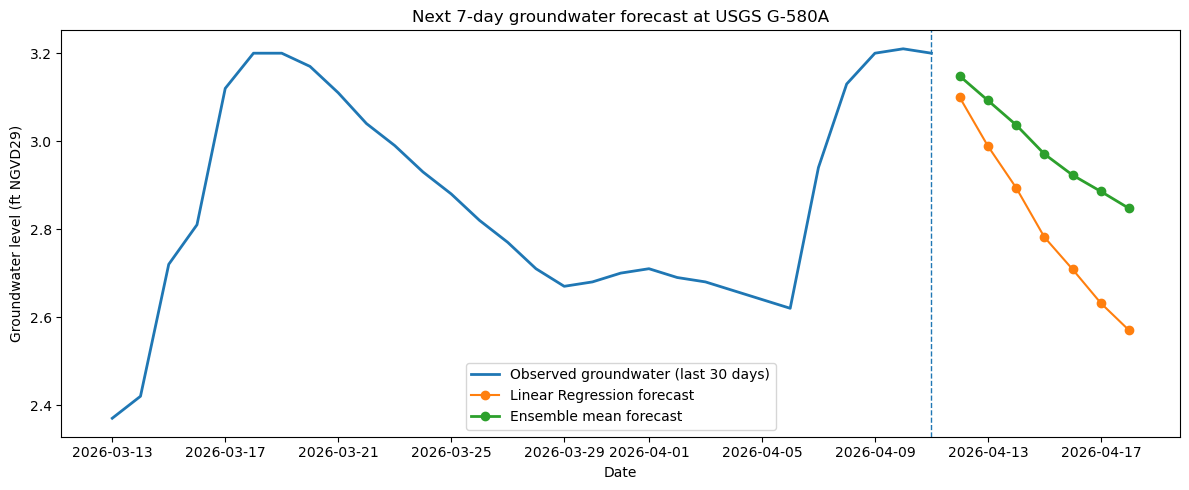

Best next-day model on the holdout test set: Linear Regression
The forecast plot shows that model together with the multi-model ensemble mean.


In [78]:
# ============================================================
# 16. Generate the next 7-day groundwater forecast
# ============================================================
forecast_history = data[["date", "groundwater_level_ft_ngvd29", "rain_mm", "et0_mm"]].copy()

forecast_output = future_weather[["date", "rain_mm", "et0_mm", "weather_source"]].copy()

for name, model in forecast_reg_models.items():
    model_forecast = recursive_forecast_tabular(
        model=model,
        history_df=forecast_history,
        future_weather_df=future_weather,
        horizon_days=FORECAST_HORIZON_DAYS,
    ).rename(columns={"predicted_groundwater_level_ft_ngvd29": name})

    forecast_output = forecast_output.merge(model_forecast, on="date", how="left")

lstm_7day_forecast = recursive_forecast_lstm(
    model=lstm_reg_full,
    history_df=forecast_history,
    future_weather_df=future_weather,
    horizon_days=FORECAST_HORIZON_DAYS,
    sequence_len=sequence_length,
    sequence_feature_names=sequence_feature_cols,
    seq_mean=full_sequence_mean,
    seq_std=full_sequence_std,
    target_mean=y_full_reg_mean,
    target_std=y_full_reg_std,
).rename(columns={"predicted_groundwater_level_ft_ngvd29": "LSTM"})

forecast_output = forecast_output.merge(lstm_7day_forecast, on="date", how="left")
forecast_output["Ensemble Mean"] = forecast_output[[
    "Linear Regression", "Random Forest", "XGBoost", "LSTM"
]].mean(axis=1)

print("Seven-day groundwater forecast")
display(forecast_output.round(3))

recent_history_plot = data.tail(30)[["date", "groundwater_level_ft_ngvd29"]].copy()
best_test_model_name = reg_results_df.sort_values("RMSE").iloc[0]["model"]

plt.figure(figsize=(12, 5))
plt.plot(
    recent_history_plot["date"],
    recent_history_plot["groundwater_level_ft_ngvd29"],
    label="Observed groundwater (last 30 days)",
    linewidth=2,
)
plt.plot(
    forecast_output["date"],
    forecast_output[best_test_model_name],
    marker="o",
    label=f"{best_test_model_name} forecast",
)
plt.plot(
    forecast_output["date"],
    forecast_output["Ensemble Mean"],
    marker="o",
    linewidth=2,
    label="Ensemble mean forecast",
)
plt.axvline(data["date"].max(), linestyle="--", linewidth=1)
plt.title("Next 7-day groundwater forecast at USGS G-580A")
plt.xlabel("Date")
plt.ylabel("Groundwater level (ft NGVD29)")
plt.legend()
plt.tight_layout()
plt.show()

print("Best next-day model on the holdout test set:", best_test_model_name)
print("The forecast plot shows that model together with the multi-model ensemble mean.")

## Final teaching notes

This notebook is meant for a **beginner AI/ML class in water resources**.

### Points to emphasize in class
1. **Data and physics still matter**  
   ML does not replace hydrology. The input choice reflects hydrologic reasoning.

2. **Groundwater has memory**  
   Yesterday's groundwater level often matters a lot.

3. **Rainfall and ET₀ have opposite tendencies**
   - rainfall tends to push groundwater up
   - ET₀ tends to pull water out of the shallow system

4. **More complex models are not automatically better**
   Always compare against simple baselines.

5. **Time-based validation is essential**
   Do not randomly shuffle a forecasting problem.

## Summary
You now have a coastal Miami groundwater example that compares:
- **Linear Regression**
- **Logistic Regression**
- **Random Forest**
- **XGBoost**
- **LSTM**

The notebook now does **two forecasting tasks**:
1. **Next-day prediction** for model comparison and teaching
2. **Next 7-day groundwater forecasting** by recursively rolling the regression models forward using forecast rainfall and ET₀ inputs